Color Used: {
        "40nm C60": "#1f77b4",  # blue
        "30nm C60": "#d62728",  # red
    }

[ -3.6552753   -6.45440268  -8.39706867  -9.71177191 -10.56553302
 -11.0944247  -11.40505965 -11.56106343 -11.61366301 -11.59700177
 -11.53066023 -11.43650213 -11.31497657 -11.1790341  -11.02673398
 -10.86648574 -10.70525588 -10.53897927 -10.36557099 -10.18815468
 -10.01289647  -9.83358559  -9.65385605  -9.4736736   -9.2914101
  -9.10936428  -8.92618796  -8.74291243  -8.5583474   -8.37329114
  -8.18762464  -8.00075681  -7.81721934  -7.63041361  -7.44391449
  -7.25908916  -7.06986448  -6.88309218  -6.69643161  -6.50955055
  -6.32129477  -6.13346618  -5.94519599  -5.75567499  -5.56839663
  -5.37866584  -5.19089525  -5.00173132  -4.81300728  -4.62384796
  -4.4344082   -4.24493426  -4.05573962  -3.86666898  -3.67744188
  -3.48700041  -3.29747978  -3.10748972  -2.91736165  -2.72723015
  -2.53724051  -2.3467625   -2.15601012  -1.96552007  -1.77501717
  -1.58408229  -1.3930253   -1.20249827  -1.01128264  -0.82026547
  -0.6290772   -0.43766191  -0.24626839  -0.05472975]
20S_1_px4_Light_forward

/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_60864/2382897505.py:383: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_filter)
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_60864/2382897505.py:493: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_60864/2382897505.py:493: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxp

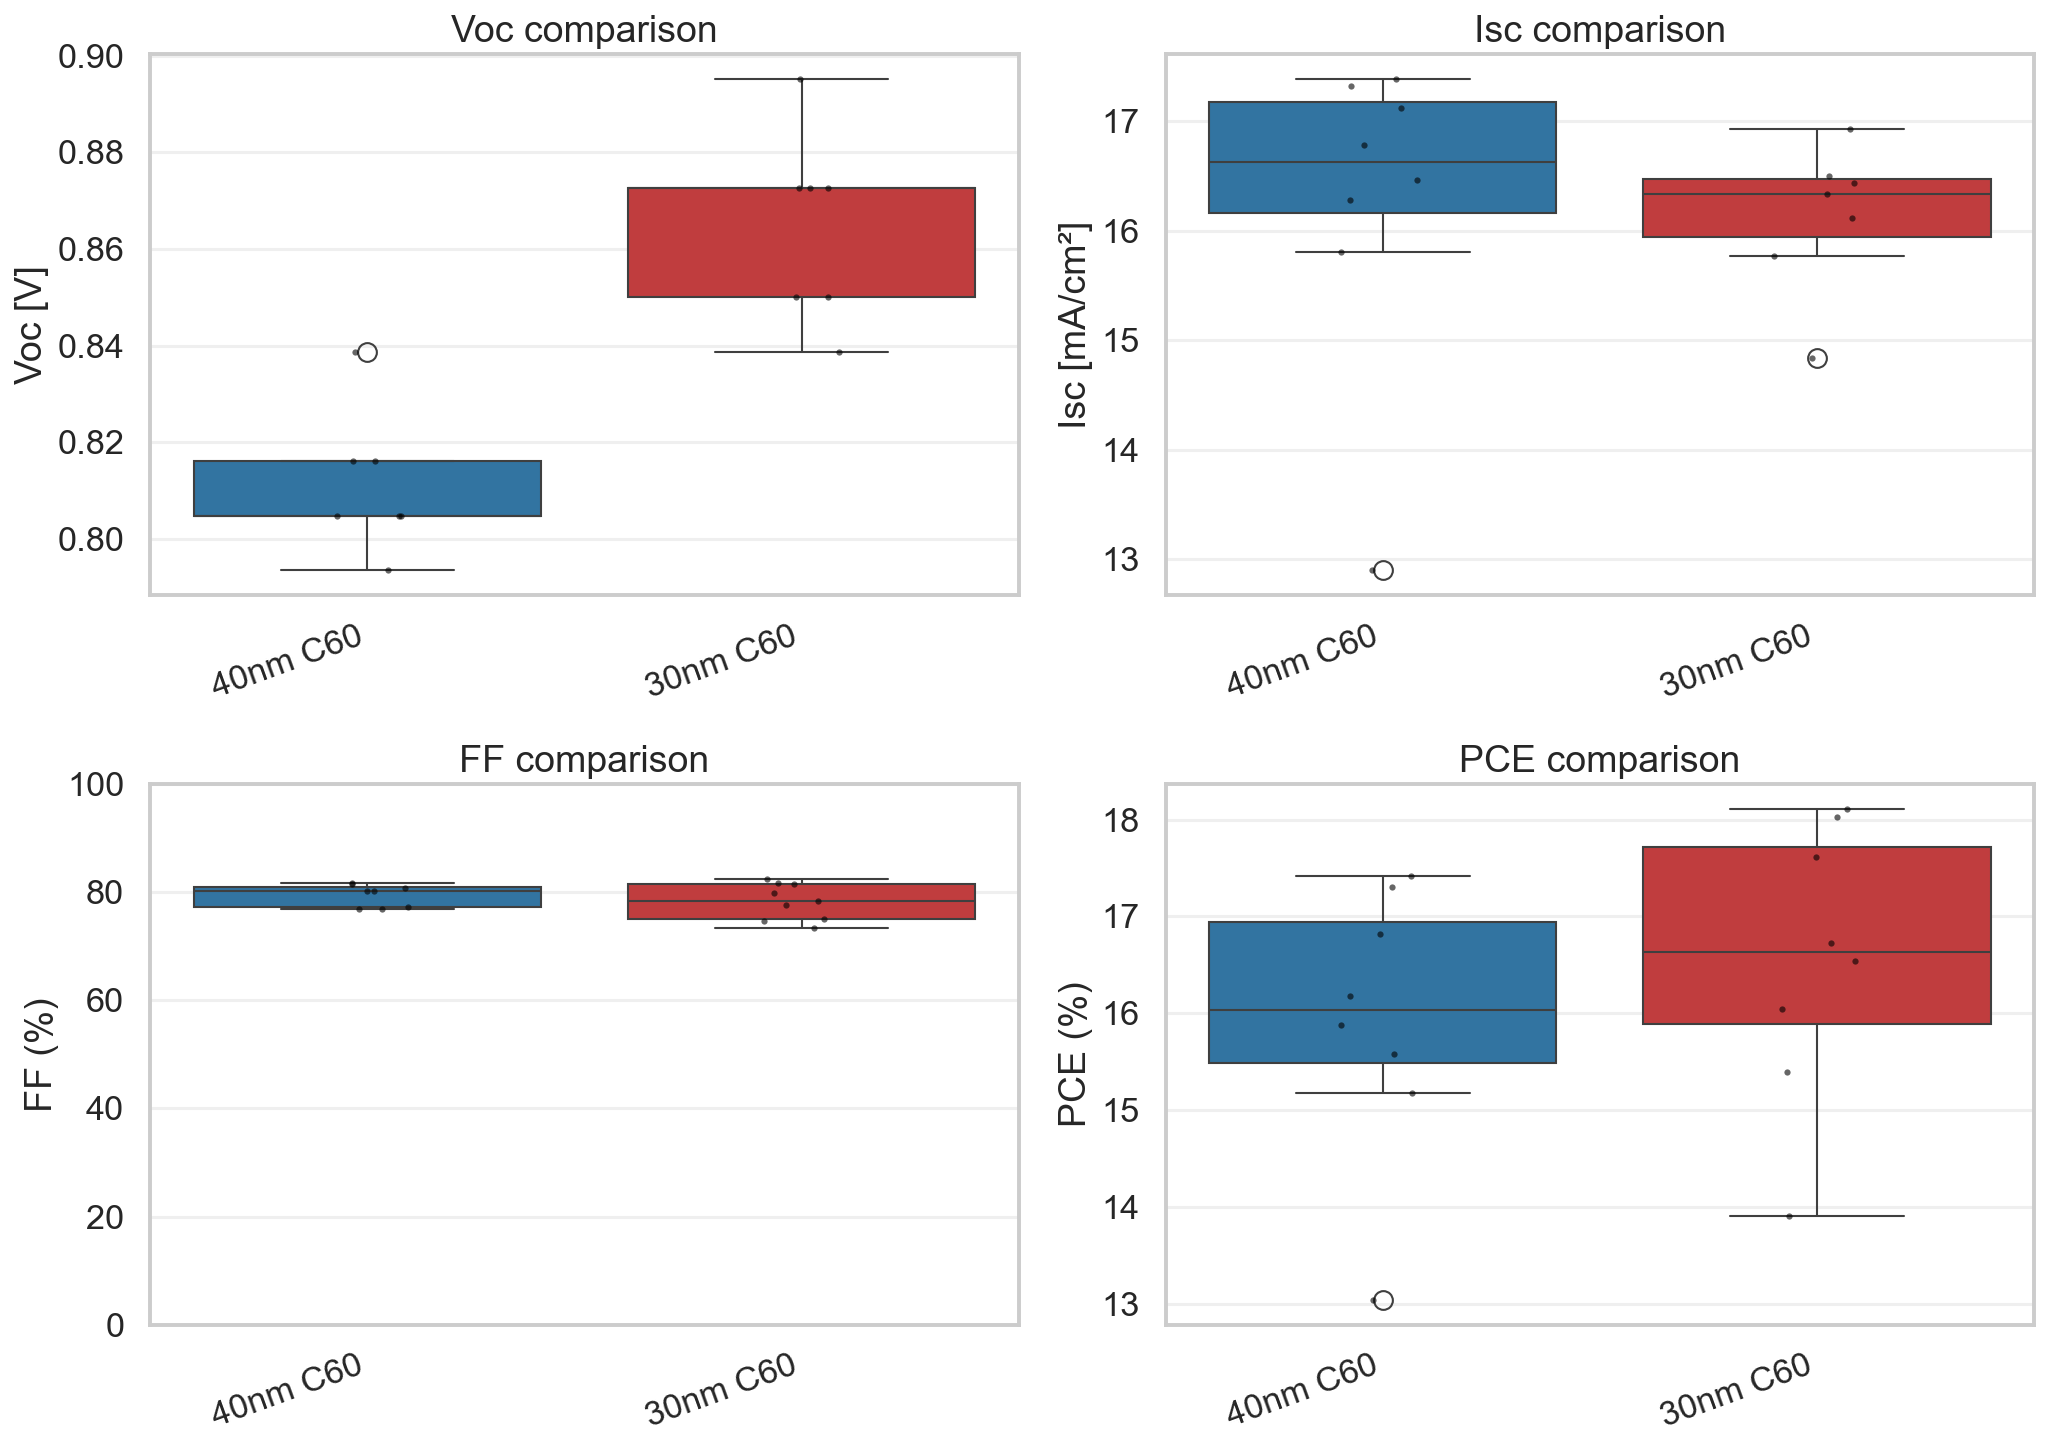

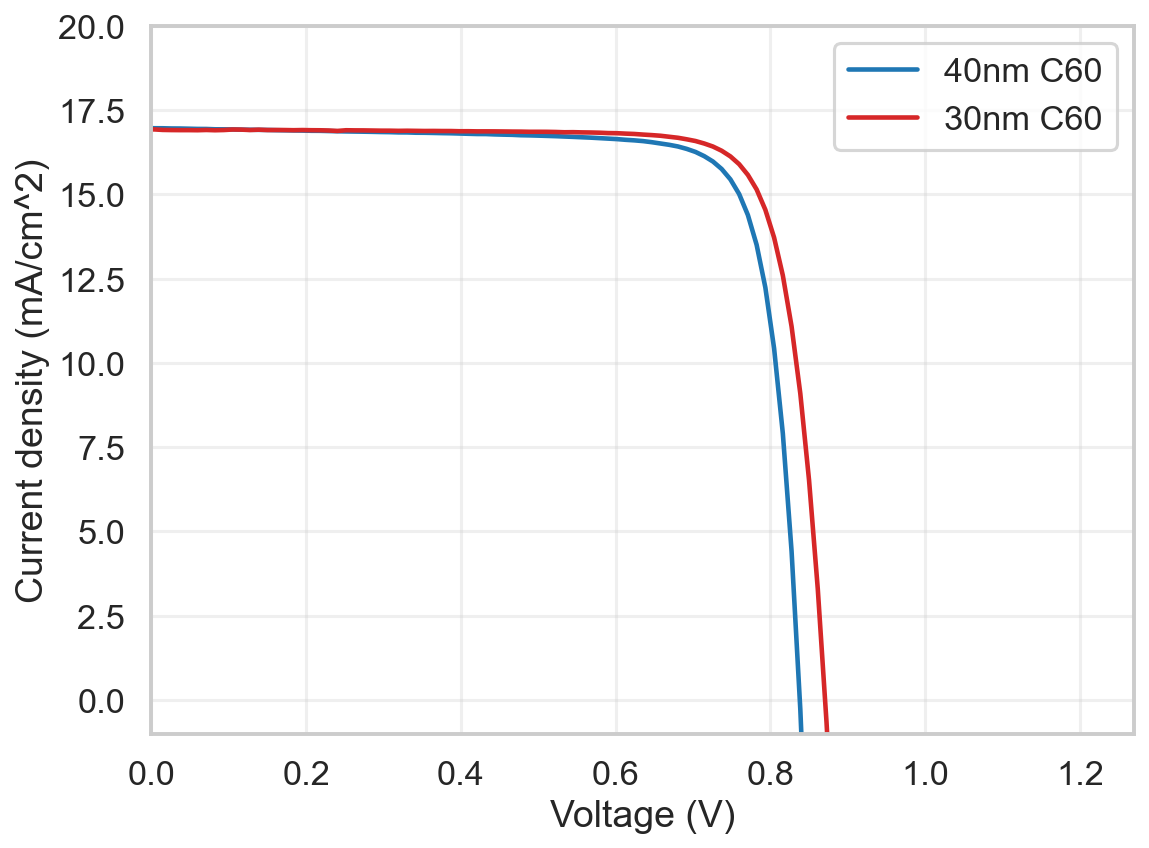

In [1]:
"""Solar simulator comparison utility for CsI samples.

Replicates the workflow of ``MA_antiSolvent_Compare.ipynb`` as a pure Python script.
Update ``FOLDER_PATH`` or ``GROUPS`` with the locations of your measurement folders
before executing this script.
"""

from __future__ import annotations

import argparse
import math
import os
from datetime import datetime
from pathlib import Path
from typing import Mapping, Sequence

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import pandas as pd
import seaborn as sns

from plot_module.solsim_analyzer import solarSimulator

sns.set(style="whitegrid", context="talk")

# Provide either a base folder that contains one sub-folder per sample or
# specify absolute/relative paths per group inside ``GROUPS``.
FOLDER_PATH: str = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data'
GROUPS: dict[str, str] = {
    "40nm C60": '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data/40nm_C60',
    "30nm C60": '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Thickness_C60/Selected_Data/30nm_C60',
}

METRIC_ORDER: Sequence[str] = ("Voc", "Isc", "FF", "PCE")
FF_METRIC = "FF"
INDIVIDUAL_METRICS: Sequence[str] = ("Voc", "Isc", "FF", "PCE")
METRIC_LABELS = {
    "Voc": "Voc [V]",
    "Isc": "Isc [mA/cm²]",
    "FF": "FF (%)",
    "PCE": "PCE (%)",
    "Rs": "Rs [Ω]",
    "Rp": "Rp [Ω]",
}


def parse_arguments() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Compare solar-simulator metrics across CsI sample groups.",
        formatter_class=argparse.ArgumentDefaultsHelpFormatter,
    )
    parser.add_argument(
        "--folder",
        default=FOLDER_PATH,
        help="Base directory that contains the measurement sub-folders.",
    )
    parser.add_argument(
        "--group",
        action="append",
        default=[],
        metavar="LABEL=PATH",
        help="Override or add a group mapping (can be passed multiple times).",
    )
    parser.add_argument(
        "--save",
        default=None,
        help="Directory where plots are written instead of showing interactively.",
    )
    parser.add_argument(
        "--no-show",
        action="store_true",
        help="Do not call plt.show(); helpful for headless runs.",
    )
    return parser.parse_args()


def parse_group_overrides(entries: Sequence[str]) -> dict[str, str]:
    overrides: dict[str, str] = {}
    for raw_entry in entries:
        if "=" not in raw_entry:
            raise SystemExit(f"Invalid --group entry '{raw_entry}'. Use LABEL=PATH format.")
        label, path = raw_entry.split("=", 1)
        label = label.strip()
        path = path.strip()
        if not label or not path:
            raise SystemExit(f"Invalid --group entry '{raw_entry}'. Label and path must be non-empty.")
        overrides[label] = path
    return overrides


def resolve_group_paths(base_folder: str, mapping: Mapping[str, str]) -> dict[str, Path]:
    resolved: dict[str, Path] = {}
    base_dir = Path(base_folder).expanduser() if base_folder else None

    for label, folder in mapping.items():
        candidate: Path | None = None
        if folder:
            candidate = Path(folder).expanduser()
        elif base_dir is not None:
            candidate = base_dir / label
        if candidate is None:
            continue
        resolved[label] = candidate

    if not resolved and base_dir is not None and base_dir.is_dir():
        for child in sorted(base_dir.iterdir()):
            if child.is_dir():
                resolved[child.name] = child

    return resolved


def load_group_analyzers(group_paths: Mapping[str, Path]) -> dict[str, solarSimulator]:
    analyzers: dict[str, solarSimulator] = {}
    for label, folder in group_paths.items():
        if not folder.is_dir():
            print(f"Skipping {label}: directory not found -> {folder}")
            continue
        if not any(folder.glob("*.dat")):
            print(f"Skipping {label}: no .dat files in {folder}")
            continue
        analyzer = solarSimulator(folderPath=str(folder))
        try:
            analyzer.loadFolderData()
        except Exception as exc:
            print(f"Skipping {label}: failed to load data ({exc})")
            continue
        analyzers[label] = analyzer
    return analyzers


def build_metric_frame(analyzers: Mapping[str, solarSimulator]) -> pd.DataFrame:
    rows: list[dict[str, float | str]] = []
    for label, analyzer in analyzers.items():
        metrics = {
            "Isc": analyzer.Isc,
            "Voc": analyzer.Voc,
            "FF": analyzer.FF,
            "PCE": analyzer.PCE,
        }
        for resistance_metric in ("Rs", "Rp"):
            resistance_values = getattr(analyzer, resistance_metric, None)
            if resistance_values is not None:
                metrics[resistance_metric] = resistance_values
        invalid_measurements: set[int] = set()
        for measurement_index, value in enumerate(metrics.get("PCE", []), start=1):
            try:
                numeric_pce = float(value)
            except (TypeError, ValueError):
                invalid_measurements.add(measurement_index)
                continue
            if not math.isfinite(numeric_pce) or numeric_pce < 1:
                invalid_measurements.add(measurement_index)

        for metric_name, values in metrics.items():
            for measurement_index, value in enumerate(values, start=1):
                if measurement_index in invalid_measurements:
                    continue
                try:
                    numeric = float(value)
                except (TypeError, ValueError):
                    continue
                if not math.isfinite(numeric):
                    continue
                rows.append({
                    "Group": label,
                    "Metric": metric_name,
                    "Measurement": measurement_index,
                    "Value": numeric,
                })
    if not rows:
        raise RuntimeError("No metrics available; check your folder paths.")

    frame = pd.DataFrame(rows)
    ff_mask = frame["Metric"] == FF_METRIC
    frame.loc[ff_mask, "Value"] = frame.loc[ff_mask, "Value"] * 100.0
    return frame


def log_metrics_to_csv(
    analyzers: Mapping[str, solarSimulator],
    filename: str = "metrics_summary.csv",
) -> None:
    for label, analyzer in analyzers.items():
        folder_path = getattr(analyzer, "folderPath", None)
        if not folder_path:
            print(f"Skipping {label}: analyzer has no folderPath defined.")
            continue
        if not analyzer.labels:
            print(f"Skipping {label}: no measurements were loaded for this group.")
            continue

        sample_count = len(analyzer.labels)

        def _normalise(values: Sequence[float] | None) -> list[float | None]:
            if values is None:
                return [None] * sample_count
            normalised = []
            for value in values:
                try:
                    numeric = float(value)
                except (TypeError, ValueError):
                    numeric = None
                if numeric is None or not math.isfinite(numeric):
                    normalised.append(None)
                else:
                    normalised.append(numeric)
            if len(normalised) < sample_count:
                normalised.extend([None] * (sample_count - len(normalised)))
            elif len(normalised) > sample_count:
                normalised = normalised[:sample_count]
            return normalised

        ff_percent = []
        for raw_ff in analyzer.FF:
            try:
                numeric_ff = float(raw_ff) if raw_ff is not None else None
            except (TypeError, ValueError):
                numeric_ff = None
            if numeric_ff is None or not math.isfinite(numeric_ff):
                ff_percent.append(None)
            else:
                ff_percent.append(numeric_ff * 100.0)
        if len(ff_percent) < sample_count:
            ff_percent.extend([None] * (sample_count - len(ff_percent)))
        elif len(ff_percent) > sample_count:
            ff_percent = ff_percent[:sample_count]

        data = {
            "Group": [label] * sample_count,
            "Sample": analyzer.labels,
            "Voc [V]": _normalise(analyzer.Voc),
            "Isc [mA/cm²]": _normalise(analyzer.Isc),
            "I_MPP [mA/cm²]": _normalise(analyzer.I_MPP),
            "V_MPP [V]": _normalise(analyzer.V_MPP),
            "FF [%]": ff_percent,
            "PCE [%]": _normalise(analyzer.PCE),
            "Rs [Ω]": _normalise(getattr(analyzer, "Rs", None)),
            "Rp [Ω]": _normalise(getattr(analyzer, "Rp", None)),
        }

        try:
            frame = pd.DataFrame(data)
        except ValueError as exc:
            print(f"Skipping {label}: failed to align metric lengths ({exc}).")
            continue

        output_path = Path(folder_path).expanduser() / filename
        try:
            frame.to_csv(output_path, index=False)
            print(f"Logged metrics for {label}: {output_path}")
        except Exception as exc:
            print(f"Failed to log metrics for {label}: {exc}")


def _normalise_metric_values(
    values: Sequence[float] | None,
    sample_count: int,
    *,
    multiplier: float = 1.0,
) -> list[float | None]:
    normalised: list[float | None] = []
    if values is None:
        normalised = [None] * sample_count
    else:
        for value in values:
            try:
                numeric = float(value)
            except (TypeError, ValueError):
                numeric = None
            if numeric is None or not math.isfinite(numeric):
                normalised.append(None)
            else:
                normalised.append(numeric * multiplier)
        if len(normalised) < sample_count:
            normalised.extend([None] * (sample_count - len(normalised)))
        elif len(normalised) > sample_count:
            normalised = normalised[:sample_count]
    return normalised


def log_cell_metrics_to_csv(
    analyzers: Mapping[str, solarSimulator],
    output_dir: Path | None,
    filename: str = "cell_metrics.csv",
) -> None:
    if output_dir is None:
        return

    records: list[dict[str, float | str | None]] = []

    for group, analyzer in analyzers.items():
        labels = getattr(analyzer, "labels", None)
        if not labels:
            continue

        sample_count = len(labels)
        voc_values = _normalise_metric_values(analyzer.Voc, sample_count)
        isc_values = _normalise_metric_values(analyzer.Isc, sample_count)
        ff_values = _normalise_metric_values(analyzer.FF, sample_count, multiplier=100.0)
        pce_values = _normalise_metric_values(analyzer.PCE, sample_count)

        for idx in range(sample_count):
            records.append(
                {
                    "Group": group,
                    "Sample": labels[idx],
                    "Voc [V]": voc_values[idx],
                    "Isc [mA/cm²]": isc_values[idx],
                    "FF [%]": ff_values[idx],
                    "PCE [%]": pce_values[idx],
                }
            )

    if not records:
        return

    output_dir.mkdir(parents=True, exist_ok=True)
    log_path = output_dir / filename
    pd.DataFrame(records).to_csv(log_path, index=False)
    print(f"Cell metrics logged to {log_path}")


def log_group_statistics(
    frame: pd.DataFrame,
    output_dir: Path | None,
    filename: str = "group_metric_stats.csv",
) -> None:
    if output_dir is None or frame.empty:
        return

    output_dir.mkdir(parents=True, exist_ok=True)

    stats = (
        frame.groupby(["Group", "Metric"])["Value"]
        .agg(sample_count="count", average="mean", std_dev="std")
        .reset_index()
    )
    stats["error"] = stats["std_dev"] / stats["sample_count"].pow(0.5)
    stats.rename(
        columns={
            "sample_count": "Sample Count",
            "average": "Average",
            "std_dev": "Std Dev",
            "error": "Error (SEM)",
        },
        inplace=True,
    )
    stats.sort_values(["Metric", "Group"], inplace=True)
    log_path = output_dir / filename
    stats.to_csv(log_path, index=False)
    print(f"Group averages logged to {log_path}")


def remove_metric_outliers(frame: pd.DataFrame, whisker: float = 1.5) -> pd.DataFrame:
    if frame.empty:
        return frame

    removed_summary: list[tuple[str, str, int]] = []

    def _filter(group: pd.DataFrame) -> pd.DataFrame:
        values = group["Value"].dropna()
        if values.empty:
            return group
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        if not math.isfinite(iqr) or iqr == 0:
            lower = q1
            upper = q3
        else:
            lower = q1 - whisker * iqr
            upper = q3 + whisker * iqr
        mask = (group["Value"] >= lower) & (group["Value"] <= upper)
        removed = int((~mask).sum())
        group_label, metric_label = group.name
        if removed:
            removed_summary.append((group_label, metric_label, removed))
        return group[mask]

    filtered = (
        frame.groupby(["Group", "Metric"], group_keys=False)
        .apply(_filter)
        .reset_index(drop=True)
    )

    if removed_summary:
        summary_lines = ", ".join(
            f"{group_label} – {metric_label}: {removed} removed"
            for group_label, metric_label, removed in removed_summary
        )
        print(f"Outliers excluded ({whisker}×IQR): {summary_lines}")

    return filtered


def _sanitize_label_for_filename(label: str) -> str:
    sanitized = "".join(char if char.isalnum() or char in {"-", "_"} else "_" for char in label)
    sanitized = sanitized.strip("_")
    return sanitized or "group"


def export_metric_tables(
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "metrics",
    combined_filename: str = "all_metrics.csv",
) -> None:
    if output_dir is None:
        return

    metrics_dir = output_dir / subfolder if subfolder else output_dir
    metrics_dir.mkdir(parents=True, exist_ok=True)

    combined_frame = frame.sort_values(["Group", "Metric", "Measurement"])
    combined_path = metrics_dir / combined_filename
    combined_frame.to_csv(combined_path, index=False)

    for group in groups_order:
        group_frame = combined_frame[combined_frame["Group"] == group]
        if group_frame.empty:
            continue
        pivot = group_frame.pivot_table(
            index="Measurement",
            columns="Metric",
            values="Value",
            aggfunc="first",
        ).sort_index()

        ordered_metrics = [metric for metric in METRIC_ORDER if metric in pivot.columns]
        remaining_metrics = [metric for metric in pivot.columns if metric not in ordered_metrics]
        if ordered_metrics or remaining_metrics:
            pivot = pivot[ordered_metrics + remaining_metrics]
        pivot.index.name = "Measurement"

        filename = f"{_sanitize_label_for_filename(group)}_metrics.csv"
        pivot.to_csv(metrics_dir / filename)

    print(f"Metric tables written to {metrics_dir}")


def show_group_means(frame: pd.DataFrame) -> None:
    means = frame.groupby(["Metric", "Group"])["Value"].mean().unstack("Group")
    print("\nGroup means (FF already converted to %):")
    print(means.round(3).to_string())
    print()


def choose_palette(labels: Sequence[str]) -> list[str]:
    custom = {
        "40nm C60": "#1f77b4",  # blue
        "30nm C60": "#d62728",  # red
    }

    fallback_palette = sns.color_palette("colorblind", max(len(labels), len(custom)))
    palette: list[str] = []

    fallback_iter = iter(fallback_palette)
    for label in labels:
        color = custom.get(label)
        if color is None:
            color = to_hex(next(fallback_iter))
        palette.append(color)
    return palette


def plot_metric_boxplots(
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "boxplots",
    filename: str = "result.png",
) -> None:
    metrics_present = [metric for metric in METRIC_ORDER if metric in frame["Metric"].unique()]
    if not metrics_present:
        return

    cols = 2
    rows = math.ceil(len(metrics_present) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows), dpi=150)
    if isinstance(axes, plt.Axes):  # single axis case
        axes = [axes]
    else:
        axes = axes.ravel()

    for ax, metric in zip(axes, metrics_present):
        subset = frame[frame["Metric"] == metric]
        if subset.empty:
            ax.axis("off")
            continue
        sns.boxplot(
            data=subset,
            x="Group",
            y="Value",
            order=groups_order,
            palette=palette,
            ax=ax,
        )
        sns.stripplot(
            data=subset,
            x="Group",
            y="Value",
            order=groups_order,
            color="black",
            size=3,
            jitter=True,
            alpha=0.6,
            ax=ax,
        )
        ax.set_xlabel("")
        label = METRIC_LABELS.get(metric, metric)
        ax.set_ylabel(label)
        if metric == FF_METRIC:
            ax.set_ylim(0, 100)
        ax.set_title(f"{metric} comparison")
        ax.grid(True, axis="y", alpha=0.3)
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
            tick.set_ha("right")

    # Hide any unused axes due to missing metrics
    for index in range(len(metrics_present), len(axes)):
        axes[index].axis("off")

    plt.tight_layout()


def plot_best_iv_curves(
    analyzers: Mapping[str, solarSimulator],
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    subfolder: str = "iv_curves",
    filename: str = "result.png",
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    color_map = dict(zip(groups_order, palette))

    for label in groups_order:
        analyzer = analyzers.get(label)
        if analyzer is None or not analyzer.PCE:
            continue
        best_idx = max(range(len(analyzer.PCE)), key=lambda idx: analyzer.PCE[idx])
        voltages = -analyzer.voltages[best_idx]
        currents = analyzer.currents[best_idx]
        ax.plot(
            voltages,
            currents,
            label=label,
            color=color_map.get(label),
            linewidth=2.2,
        )

    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("Current density (mA/cm^2)")
    ax.set_ylim(-1, 20)
    ax.set_xlim(left=0)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    #if output_dir is not None:
    #    target_dir = output_dir / subfolder if subfolder else output_dir
    #    target_dir.mkdir(parents=True, exist_ok=True)
    #    fig.savefig(target_dir / filename, dpi=300)

    #plt.close(fig)


def plot_single_metric_boxplot(
    metric: str,
    frame: pd.DataFrame,
    groups_order: Sequence[str],
    palette: Sequence[str],
    output_dir: Path | None,
    base_subfolder: str = "boxplots",
    filename: str = "result.png",
) -> None:
    subset = frame[frame["Metric"] == metric]
    if subset.empty:
        return

    fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
    sns.boxplot(
        data=subset,
        x="Group",
        y="Value",
        order=groups_order,
        palette=palette,
        ax=ax,
    )
    sns.stripplot(
        data=subset,
        x="Group",
        y="Value",
        order=groups_order,
        color="black",
        size=4,
        jitter=True,
        alpha=0.7,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    if metric == FF_METRIC:
        ax.set_ylim(0, 100)
    ax.set_title(f"{metric} comparison")
    ax.grid(True, axis="y", alpha=0.3)
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
        tick.set_ha("right")

    plt.tight_layout()

    #if output_dir is not None:
    #    target_dir = output_dir / base_subfolder / metric
    #    target_dir.mkdir(parents=True, exist_ok=True)
    #    fig.savefig(target_dir / filename, dpi=300)

    #plt.close(fig)


def main() -> None:
    args = parse_arguments()
    group_mapping = dict(GROUPS)
    group_mapping.update(parse_group_overrides(args.group))
    group_paths = resolve_group_paths(args.folder, group_mapping)
    if not group_paths:
        raise SystemExit("No group directories resolved. Update FOLDER_PATH or supply --group arguments.")

    analyzers = load_group_analyzers(group_paths)
    if not analyzers:
        raise SystemExit("No analyzers created. Ensure the folders contain .dat files.")

    frame = build_metric_frame(analyzers)
    frame = remove_metric_outliers(frame)
    log_metrics_to_csv(analyzers)
    show_group_means(frame)

    groups_order = [label for label in group_paths if label in analyzers]
    palette = choose_palette(groups_order)
    output_dir = Path(args.save).expanduser() if args.save else None
    auto_output_dir = False
    if output_dir is None:
        auto_output_dir = True
        candidate_dirs = [path for path in group_paths.values()]
        base_dir: Path
        if args.folder:
            base_dir = Path(args.folder).expanduser()
        else:
            try:
                base_dir = Path(os.path.commonpath([str(path.parent) for path in candidate_dirs]))
            except ValueError:
                base_dir = candidate_dirs[0].parent
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_dir = base_dir / f"Result+{timestamp}"

    #log_cell_metrics_to_csv(analyzers, output_dir)
    #log_group_statistics(frame, output_dir)
    #export_metric_tables(frame, groups_order, output_dir)
    plot_metric_boxplots(frame, groups_order, palette, output_dir)
    #for metric in INDIVIDUAL_METRICS:
    #    plot_single_metric_boxplot(metric, frame, groups_order, palette, output_dir)
    plot_best_iv_curves(analyzers, groups_order, palette, output_dir)

    #if auto_output_dir:
    #    print(f"Plots saved to {output_dir}")


if __name__ == "__main__":
    main()


In [ ]:
print()

NameError: name 'analyzers' is not defined